# Virtual dataset reader and plotter
### Example for NASA CMR Shortname: SWOT_L2_LR_SSH_Basic_D

#### *Author: Ed Armstrong, PO.DAAC*

*Reference herein to any specific commercial product, process, or service by trade name, trademark, manufacturer, or otherwise, does not constitute or imply its endorsement by the United States Government or the Jet Propulsion Laboratory, California Institute of Technology.*

### Necessary enviroment includes
##### earthaccess                   0.16.0
##### fsspec                        2025.9.0
##### kerchunk                      0.2.7
##### numpy                         2.3.3
##### xarray                        2025.1.2
#####  zarr                          2.18.6

In [ ]:
# install these versions as needed.  Create a seperate environment for these dependencies and run it from there.
#!pip install earthaccess==0.16.0 xarray==2025.1.2 zarr==2.18.6  fsspec>=2025.2 numpy virtualizarr==1.3.2 "numcodecs<0.16.0" kerchunk==0.2.7

In [1]:
pip list | grep -E  -e  '(^xarray|numpy|earthaccess|fsspec|zarr|kerchunk)'

if: Expression Syntax.
then: Command not found.
earthaccess               0.16.0
fsspec                    2026.3.0
kerchunk                  0.2.7
numpy                     2.2.4
virtualizarr              1.3.2
xarray                    2025.1.2
zarr                      2.18.6
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Filesystem management 
import fsspec
import earthaccess

# Data handling
import xarray as xr
import zarr 

# Numpy
import numpy as np

# Other mapping
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

## 1. Earthdata Cloud authentication


In [3]:
# Get Earthdata creds
earthaccess.login()

## 2. Perform CMR search request and Open VDS reference file

In [4]:
%%time
# Do a simple CMR granule search. We need the results of the granule search to establish AWS credentials if reading the VDS 
# in the cloud.  Otherwise ignore

lat_min, lat_max = -80, 20
lon_min, lon_max = 0, 120

start_time = '2025-05-10T00:28:00'
end_time = '2025-05-10T23:28:00'

short_name = 'SWOT_L2_LR_SSH_Basic_D'
granule_result = earthaccess.search_data(
    short_name=short_name,
    temporal=(start_time, end_time),
    bounding_box=(lon_min, lat_min, lon_max, lat_max)
)
print(len(granule_result))

14
CPU times: user 13.9 ms, sys: 4.18 ms, total: 18.1 ms
Wall time: 1.05 s


### 2a. VDS wrapper function for access in cloud or out of cloud

In [5]:
# Open data using the reference file, using a small wrapper function around xarray's open_dataset. 
# This will shorten code blocks in other sections. 
def get_vds_mapper(vds_link, in_cloud_region=False):
    """
    Produces a virtudal dataset mapper that can be passed to xarray. 
    
    * vds_link: str, link to the mapper
    * in_cloud_region: bool, True if in cloud in the same region as the data, 
        False otherwise.
    """

    if in_cloud_region:
        #fs_data = earthaccess.get_s3_filesystem(daac="PODAAC")
        fs_data = earthaccess.get_s3_filesystem(results=granule_result)
        remote_protocol = "s3"
    else:
        fs_data = earthaccess.get_fsspec_https_session()
        # We set this header to identify usage of the VDS. This helps us support continued development. 
        fs_data.client_kwargs['headers']['User-Agent'] = "virtual-dataset-consumer"
        remote_protocol = "https"
    
    storage_opts = {"fo": vds_link, "remote_protocol": remote_protocol, "remote_options": fs_data.storage_options}
    fs_ref = fsspec.filesystem('reference', **storage_opts)
    return fs_ref.get_mapper('')

### 2b. Open VDS as xarray dataset

In [6]:
%%time

# Path to VDSs, both HTTPS and S3 versions
vds_link= 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-public/virtual_collections/SWOT_L2_LR_SSH_Basic_D/SWOT_L2_LR_SSH_Basic_D_virtual_https.json'
#vds_link= 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-public/virtual_collections/SWOT_L2_LR_SSH_Basic_D/SWOT_L2_LR_SSH_Basic_D_virtual_s3.json'


# Lets open the JSON VDS as xarray dataset
vds_mapper = get_vds_mapper(vds_link, in_cloud_region=False)

## No modification needed!
data_vds = xr.open_dataset(
    vds_mapper, engine="zarr", chunks={},
    backend_kwargs={"consolidated": False}
)
data_vds
#print(data)


CPU times: user 2.69 s, sys: 529 ms, total: 3.22 s
Wall time: 11 s


<xarray.Dataset> Size: 3TB
Dimensions:                                (granule: 26175, num_lines: 9866,
                                            num_pixels: 69, num_sides: 2)
Coordinates:
    cycle                                  (granule) float64 209kB dask.array<chunksize=(26175,), meta=np.ndarray>
    filename                               (granule) object 209kB dask.array<chunksize=(26175,), meta=np.ndarray>
  * granule                                (granule) float64 209kB nan ... 2....
    latitude                               (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    longitude                              (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    orbit                                  (granule) datetime64[ns] 209kB dask.array<chunksize=(26175,), meta=np.ndarray>
    ppass                                  (granule) float64 209kB dask.array<chunksize=(26175,), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    ancillary_surface_classification_flag  (granule, num_lines, num_pixels) float32 71GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    distance_to_coast                      (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    dynamic_ice_flag                       (granule, num_lines, num_pixels) float32 71GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    geoid                                  (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    heading_to_coast                       (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    height_cor_xover                       (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ...                                     ...
    ssha_karin                             (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2                           (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2_qual                      (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_qual                        (granule, num_lines, num_pixels) float64 143GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    time                                   (granule, num_lines) datetime64[ns] 2GB dask.array<chunksize=(1, 9866), meta=np.ndarray>
    time_tai                               (granule, num_lines) datetime64[ns] 2GB dask.array<chunksize=(1, 9866), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                      CF-1.7
    title:                            Level 2 Low Rate Sea Surface Height Dat...
    institution:                      CNES
    source:                           Ka-band radar interferometer
    platform:                         SWOT
    reference_document:               D-56407_SWOT_Product_Description_L2_LR_SSH
    ...                               ...
    xref_param_l2_lr_precalssh_file:  SWOT_Param_L2_LR_PreCalSSH_20000101T000...
    xref_reforbittrack_files:         SWOT_RefOrbitTrack125mPass1_Nom_2000010...
    xref_geco_database_version:       v107
    ellipsoid_semi_major_axis:        6378137.0
    ellipsoid_flattening:             0.0033528106647474805
    references:                       V1.4.1

In [30]:
print(data_vds.isel(granule=26174).filename.values)

SWOT_L2_LR_SSH_Basic_048_283_20260406T224034_20260406T233202_PID0_01.nc


In [8]:
# number of orbits
data_vds.dims["granule"]

/var/folders/c4/bkn3x29559ggcdlgd9grtx4m0000gp/T/ipykernel_71055/869051093.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data_vds.dims["granule"]


26175

In [9]:
# find the unique orbits.. user needs to track the non-unique ones

n_orbits = np.unique(data_vds.orbit.values).size
print(n_orbits)

25531


## 3. Perform data discovery, masking and plots
### 3a. Use case 1:  Parse granule metadata from CMR search request to find the start times of the orbits and use to subset into the VDS, mask and plot

In [10]:
# Do a CMR granule search and find the orbits in a specific space/time window. SWOT is 0-360 in longitude.
# This bbox for Indian/Southern Ocean
lat_min, lat_max = -80, 20
lon_min, lon_max = 0, 120

start_time = '2025-05-10T00:28:00'
end_time = '2025-05-10T23:28:00'

short_name = 'SWOT_L2_LR_SSH_Basic_D'
#short_name = 'SCATSAT1_ESDR_L2_WIND_STRESS_V1.1'

granule_result = earthaccess.search_data(
    short_name=short_name,
    temporal=(start_time, end_time),
    bounding_box=(lon_min, lat_min, lon_max, lat_max)
)
print(len(granule_result))


14


In [11]:
# Get granule start times from CMR granule search result. Will be used to subset into the VDS:
datetimes_str = [g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime'][:-1] for g in granule_result]  # -1 to remove "Z" at end.
datetimes_obj = [np.datetime64(dts) for dts in datetimes_str]
#print(datetimes_obj)

In [12]:
# Subset into VDS ---- THIS DOES NOT WORK....the orbits represented by datetime_obj are not consecutive....re indexing does not work
#data_vds_subset = data_vds.sel(orbit = datetimes_obj)
#data_vds_subset


In [13]:
# Mask (and subset)the entire VDS with the orbits found from the CMR space/time query and granule metadata parsing for start times
mask = data_vds.orbit.isin(datetimes_obj).compute()
data_vds_subset = data_vds.where(mask, drop=True)
data_vds_subset

<xarray.Dataset> Size: 2GB
Dimensions:                                (granule: 14, num_lines: 9866,
                                            num_pixels: 69, num_sides: 2)
Coordinates:
    cycle                                  (granule) float64 112B 32.0 ... 32.0
    filename                               (granule) object 112B 'SWOT_L2_LR_...
  * granule                                (granule) float64 112B 1.657e+04 ....
    latitude                               (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    longitude                              (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    orbit                                  (granule) datetime64[ns] 112B 2025...
    ppass                                  (granule) float64 112B 340.0 ... 3...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    ancillary_surface_classification_flag  (granule, num_lines, num_pixels) float32 38MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    distance_to_coast                      (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    dynamic_ice_flag                       (granule, num_lines, num_pixels) float32 38MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    geoid                                  (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    heading_to_coast                       (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    height_cor_xover                       (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ...                                     ...
    ssha_karin                             (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2                           (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2_qual                      (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_qual                        (granule, num_lines, num_pixels) float64 76MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    time                                   (granule, num_lines) datetime64[ns] 1MB dask.array<chunksize=(1, 9866), meta=np.ndarray>
    time_tai                               (granule, num_lines) datetime64[ns] 1MB dask.array<chunksize=(1, 9866), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                      CF-1.7
    title:                            Level 2 Low Rate Sea Surface Height Dat...
    institution:                      CNES
    source:                           Ka-band radar interferometer
    platform:                         SWOT
    reference_document:               D-56407_SWOT_Product_Description_L2_LR_SSH
    ...                               ...
    xref_param_l2_lr_precalssh_file:  SWOT_Param_L2_LR_PreCalSSH_20000101T000...
    xref_reforbittrack_files:         SWOT_RefOrbitTrack125mPass1_Nom_2000010...
    xref_geco_database_version:       v107
    ellipsoid_semi_major_axis:        6378137.0
    ellipsoid_flattening:             0.0033528106647474805
    references:                       V1.4.1

#### Mask the SSH data for a valid range

In [14]:
# Perform SSH variable maskings for the large numeric  "fill_values" and other assignments
ssh = data_vds_subset.ssh_karin
ssh = ssh.where(ssh < 1000)

lat = data_vds_subset.latitude
lon = data_vds_subset.longitude

#### Plot it

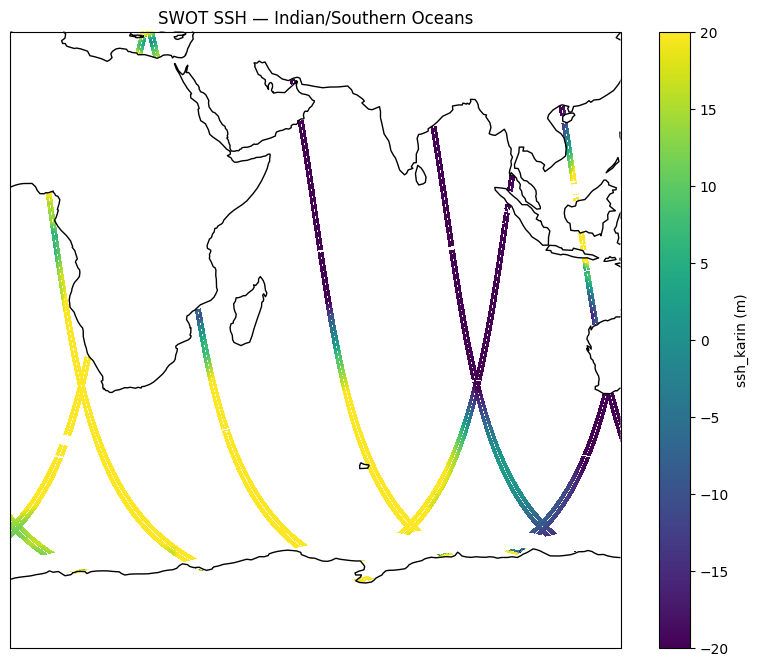

CPU times: user 13.3 s, sys: 1.71 s, total: 15 s
Wall time: 45.4 s


In [15]:
%%time

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.coastlines()

for k in range(ssh.sizes["granule"]):
    ssh_i = ssh.isel(granule=k).load()
    lat_i = lat.isel(granule=k).load()
    lon_i = lon.isel(granule=k).load()
    
    pcm = ax.pcolormesh(
        lon_i,
        lat_i,
        ssh_i,
        shading="auto",
        cmap="viridis",
        vmin=-20,
        vmax=20,
        transform=ccrs.PlateCarree()
    )

plt.colorbar(pcm, ax=ax, label="ssh_karin (m)")
plt.title("SWOT SSH — Indian/Southern Oceans")
plt.show()

### 3b. Use case 2:  Find all the cycles/passes over a specific (small) region and create an average SSHA time series plot.
### We will choose pass 289  over a region off central California around 123W, 34N, 121W, 36N 

In [16]:
target_pass = 289

ds = data_vds.where(data_vds.ppass.compute() == target_pass, drop=True)
ds

<xarray.Dataset> Size: 5GB
Dimensions:                                (granule: 45, num_lines: 9866,
                                            num_pixels: 69, num_sides: 2)
Coordinates:
    cycle                                  (granule) float64 360B 1.0 ... 47.0
    filename                               (granule) object 360B 'SWOT_L2_LR_...
  * granule                                (granule) float64 360B 154.0 ... 2...
    latitude                               (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    longitude                              (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    orbit                                  (granule) datetime64[ns] 360B 2023...
    ppass                                  (granule) float64 360B 289.0 ... 2...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    ancillary_surface_classification_flag  (granule, num_lines, num_pixels) float32 123MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    distance_to_coast                      (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    dynamic_ice_flag                       (granule, num_lines, num_pixels) float32 123MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    geoid                                  (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    heading_to_coast                       (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    height_cor_xover                       (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ...                                     ...
    ssha_karin                             (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2                           (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2_qual                      (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_qual                        (granule, num_lines, num_pixels) float64 245MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    time                                   (granule, num_lines) datetime64[ns] 4MB dask.array<chunksize=(1, 9866), meta=np.ndarray>
    time_tai                               (granule, num_lines) datetime64[ns] 4MB dask.array<chunksize=(1, 9866), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                      CF-1.7
    title:                            Level 2 Low Rate Sea Surface Height Dat...
    institution:                      CNES
    source:                           Ka-band radar interferometer
    platform:                         SWOT
    reference_document:               D-56407_SWOT_Product_Description_L2_LR_SSH
    ...                               ...
    xref_param_l2_lr_precalssh_file:  SWOT_Param_L2_LR_PreCalSSH_20000101T000...
    xref_reforbittrack_files:         SWOT_RefOrbitTrack125mPass1_Nom_2000010...
    xref_geco_database_version:       v107
    ellipsoid_semi_major_axis:        6378137.0
    ellipsoid_flattening:             0.0033528106647474805
    references:                       V1.4.1

In [17]:
lon_min, lon_max = 237.5, 238.8
lat_min, lat_max = 34.5, 35.5
mask = (
    (ds.longitude >= lon_min) & (ds.longitude <= lon_max) &
    (ds.latitude  >= lat_min) & (ds.latitude  <= lat_max)
)

In [18]:
ssh = ds.ssha_karin.where(ds.ssha_karin < 1000)
ssh_box = ssh.where(mask)

In [19]:
ssh_mean = ssh_box.mean(dim=("num_lines", "num_pixels"), skipna=True)

In [20]:
ssh_mean = ssh_mean.assign_coords(time=ds.orbit)
ssh_mean = ssh_mean.swap_dims({"granule": "time"})
ssh_mean = ssh_mean.sortby("time")

In [21]:
ssh_ts = ssh_mean.groupby("time").mean()

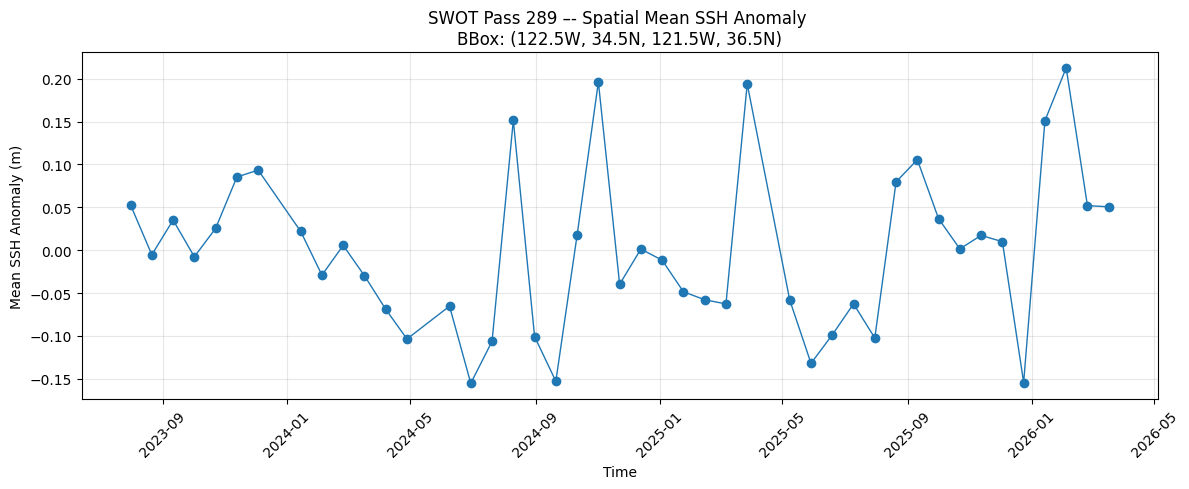

In [22]:
plt.figure(figsize=(12,5))

plt.plot(ssh_ts.time, ssh_ts, marker='o', linewidth=1)

plt.title("SWOT Pass 289 –- Spatial Mean SSH Anomaly \nBBox: (122.5W, 34.5N, 121.5W, 36.5N)")
plt.xlabel("Time")
plt.ylabel("Mean SSH Anomaly (m)")
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3c. Use case 3: Spatially plot just a specific cycle/pass from our previous time series (plot one time step)





In [23]:
ds = data_vds.where(
    (data_vds.cycle.compute() == 29) & (data_vds.ppass.compute() == 289),
    drop=True
)

# find the granule number (index) for this cycle/pass
granule_index = ds.granule.values

In [24]:
ssh = ds.ssha_karin.where(ds.ssh_karin < 1000)

lat = ds.latitude
lon = ds.longitude

In [25]:
ssh = ssh.squeeze()
lat = lat.squeeze()
lon = lon.squeeze()

In [26]:
# swath plot area
lon_min, lon_max = 232, 240
lat_min, lat_max = 30, 40

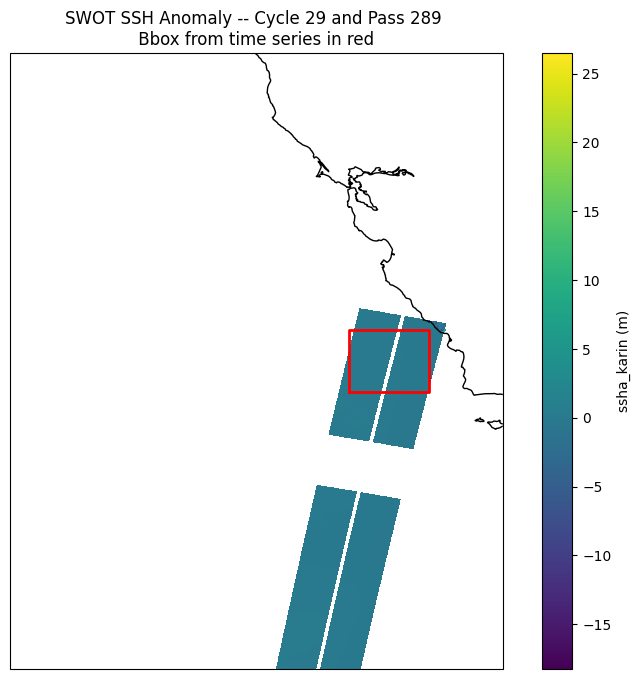

In [27]:
# Do the spatial plot
fig = plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.coastlines()


pcm = ax.pcolormesh(
    lon,
    lat,
    ssh,
    shading="auto"
)

plt.colorbar(pcm, ax=ax, label="ssha_karin (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("SWOT SSH Anomaly -- Cycle 29 and Pass 289 \n Bbox from time series in red ")
plt.grid(alpha=0.3)

# add the orginal bounding box (spatial average) outline
lon_min, lon_max = 237.5, 238.8
lat_min, lat_max = 34.5, 35.5
bbox_lon = [lon_min, lon_max, lon_max, lon_min, lon_min]
bbox_lat = [lat_min, lat_min, lat_max, lat_max, lat_min]

ax.plot(
    bbox_lon,
    bbox_lat,
    color="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

plt.show()